### Прогноз цен на авиабилеты

Авиакомпания — это компания, предоставляющая услуги воздушных перевозок пассажиров и грузов. Авиакомпании используют самолеты для предоставления этих услуг и могут заключать партнерские соглашения или альянсы с другими авиакомпаниями в рамках соглашений о код-шеринге, согласно которым они обе предлагают и выполняют один и тот же рейс. Как правило, авиакомпании признаются на основании сертификата или лицензии на осуществление воздушных перевозок, выданной государственным авиационным органом. Авиакомпании могут быть регулярными или чартерными операторами.

Авиакомпании устанавливают цены на свои услуги, стремясь максимизировать прибыль. Ценообразование авиабилетов с годами стало значительно сложнее и в настоящее время в значительной степени определяется компьютеризированными системами управления доходностью.

Цена авиабилета зависит от ряда факторов, таких как продолжительность полета, количество дней до вылета, время прибытия и отправления и т. д. Авиакомпании могут снижать стоимость в моменты, когда им необходимо нарастить спрос, и в моменты, когда билеты менее доступны. Они также могут максимизировать затраты. Цена может зависеть от различных факторов. Каждый фактор имеет свои собственные правила и алгоритмы для установления соответствующей цены. Последние достижения в области искусственного интеллекта (ИИ) и машинного обучения (МО) позволяют выводить такие правила и моделировать изменение цены.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

### Загрузка данных

In [12]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)

In [13]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Описание набора данных

* **Airline** (Авиакомпания): Название авиакомпании хранится в столбце «Авиакомпания». Это категория, включающая 6 различных авиакомпаний.
* **Flight** (Рейс): Flight хранит информацию о коде рейса самолета. Это категориальный признак.
* **Source City** (Город-источник): Город, из которого вылетает самолет. Это категория, включающая 6 уникальных городов.
* **Departure Time** (Время отправления): это производная категориальная характеристика, полученная путем группировки временных периодов в интервалы. Она хранит информацию о времени отправления и имеет 6 уникальных временных меток.
* **Stops** (Остановки):Категориальный признак с тремя различными значениями, хранящий количество остановок между городами отправления и назначения.
* **Arrival Time** (Время прибытия): это производная категориальная характеристика, созданная путем группировки временных интервалов в интервалы. Она имеет шесть различных временных меток и содержит информацию о времени прибытия.
* **Destination City** (Город назначения): Город, где приземлится самолет. Это категория, включающая 6 уникальных городов.
* **Class** (Класс): Категориальный признак, содержащий информацию о классе места; имеет два различных значения: Бизнес и Эконом.
* **Duration** (Продолжительность): Непрерывный параметр, отображающий общее время, необходимое для поездки между городами в часах.
* **Days Left** (Осталось дней): это производная характеристика, которая рассчитывается путем вычитания даты поездки из даты бронирования.
* **Price** (Цена): Целевая переменная хранит информацию о цене билета.
не билета.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [15]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [16]:
df.describe(include='O')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## Разведочный анализ данных (РАД, EDA)

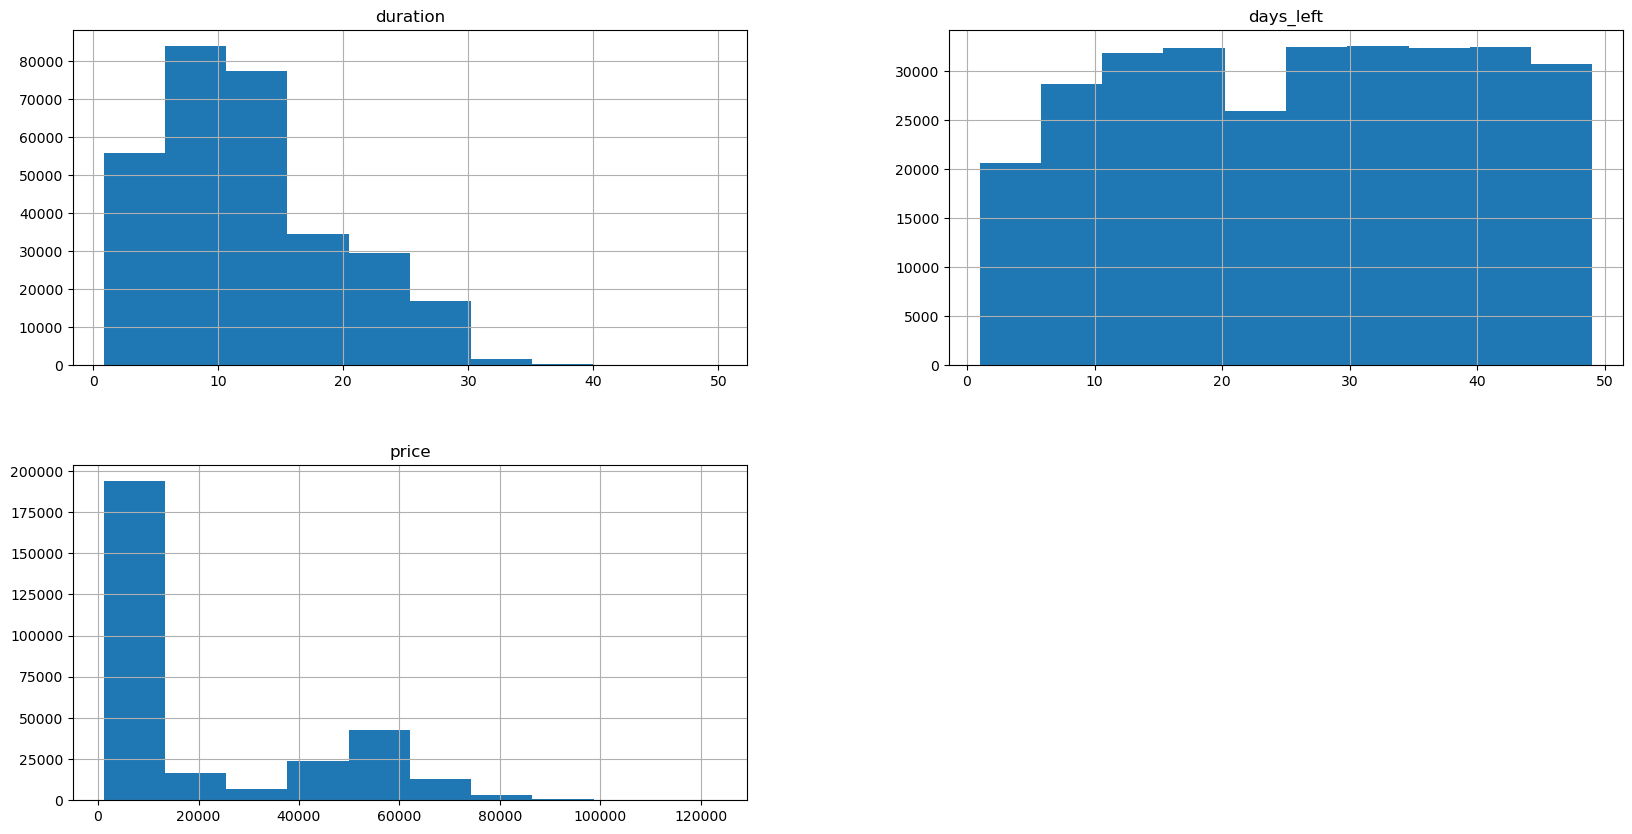

In [17]:
df.hist(figsize=(20,10));

In [18]:
cat_features = [column for column in df.columns if df[column].dtype =="object"]

In [19]:
cat_features

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class']

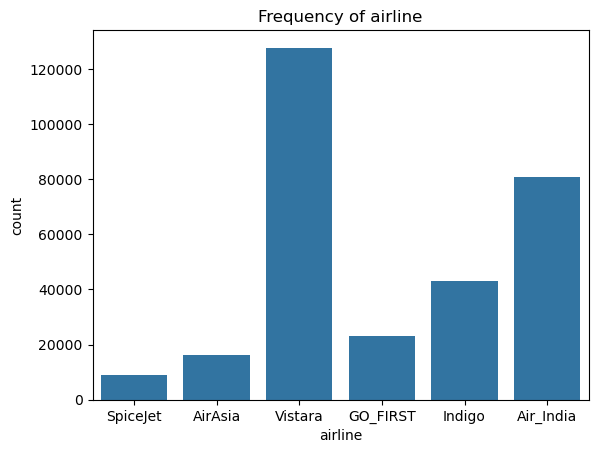

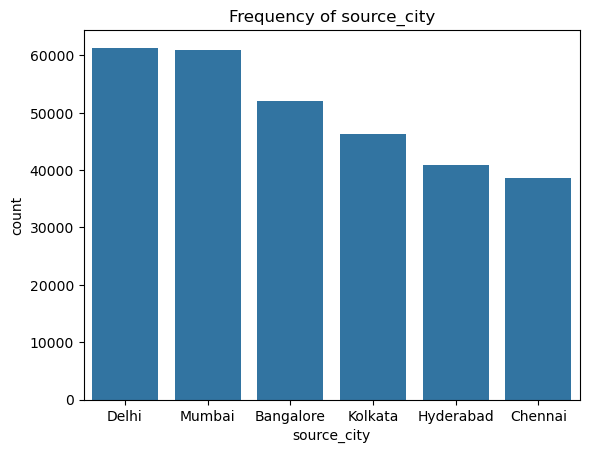

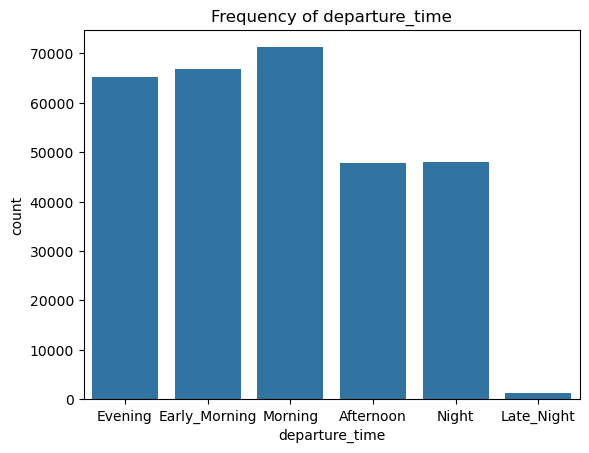

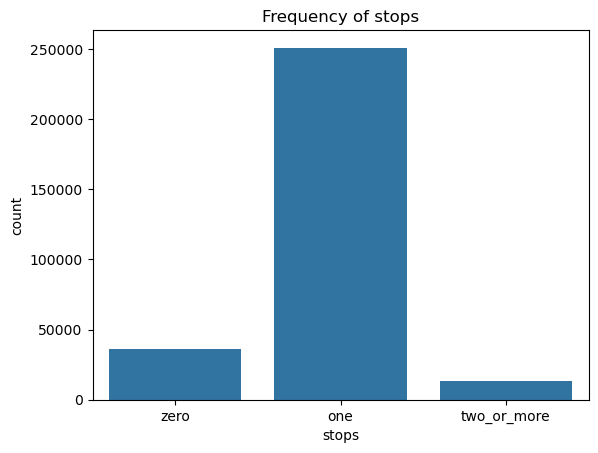

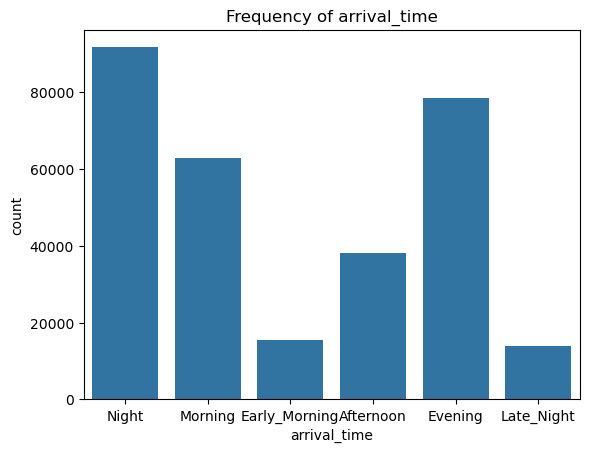

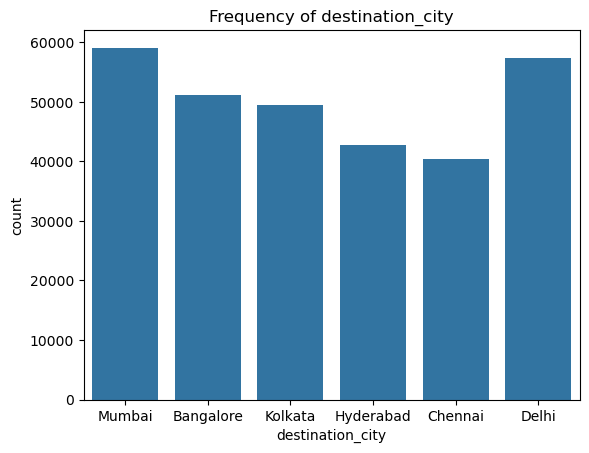

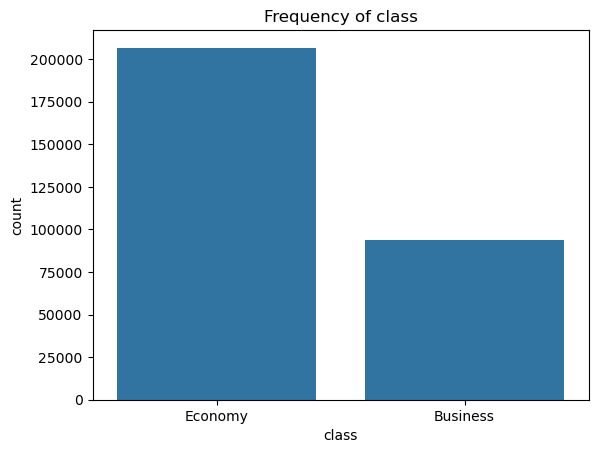

In [20]:
for column in cat_features:
    if column != 'flight':
        sns.countplot(x=df[column], data=df)
        plt.title("Frequency of " + column)
        plt.show()

In [21]:
df[df['flight']=='SG-8709']

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
...,...,...,...,...,...,...,...,...,...,...,...
42049,SpiceJet,SG-8709,Delhi,Evening,one,Early_Morning,Chennai,Economy,13.08,43,4942
42053,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.42,43,4942
42228,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.83,44,4942
42381,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,27.00,45,4942


In [22]:
df[df['flight']=='SG-8709'].head(20)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
919,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,7,5953
1105,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,8,5953
1331,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,9,6060
1493,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,10,6270
1644,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,11,5953


In [23]:
df1=df.groupby(['flight','airline'],as_index=False).count()
df1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

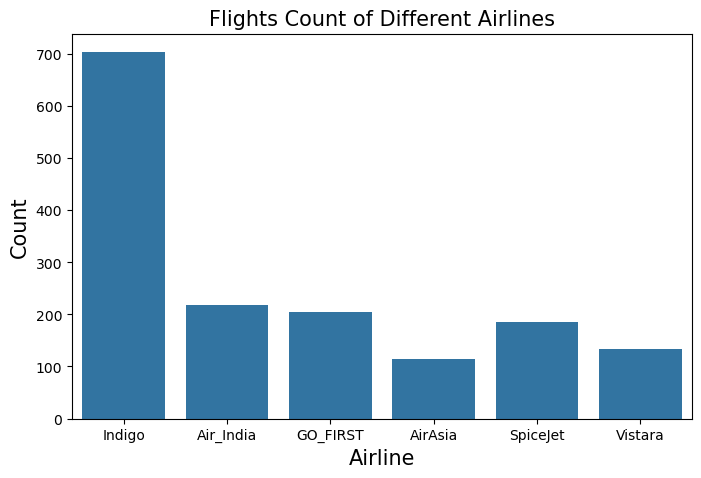

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x=df1['airline'])
plt.title('Flights Count of Different Airlines',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

Индиго одна из самых популярных авиакомпаний.

In [25]:
df2=df.groupby(['flight','airline','class'],as_index=False).count()
df2['class'].value_counts()

class
Economy     1560
Business     295
Name: count, dtype: int64

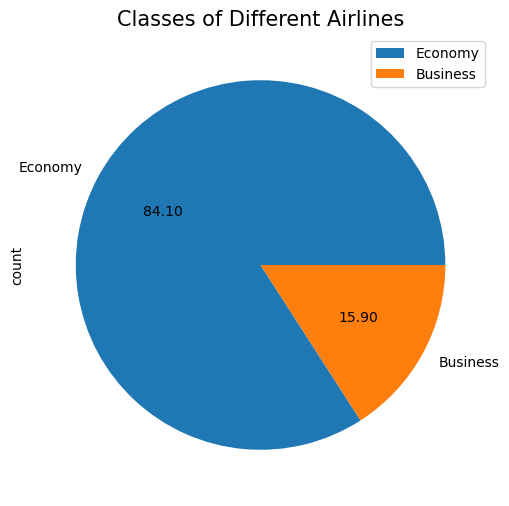

In [26]:
plt.figure(figsize=(8,6))
df2['class'].value_counts().plot(kind='pie',textprops={'color':'black'},autopct='%.2f')
plt.title('Classes of Different Airlines',fontsize=15)
plt.legend(['Economy','Business'])
plt.show()

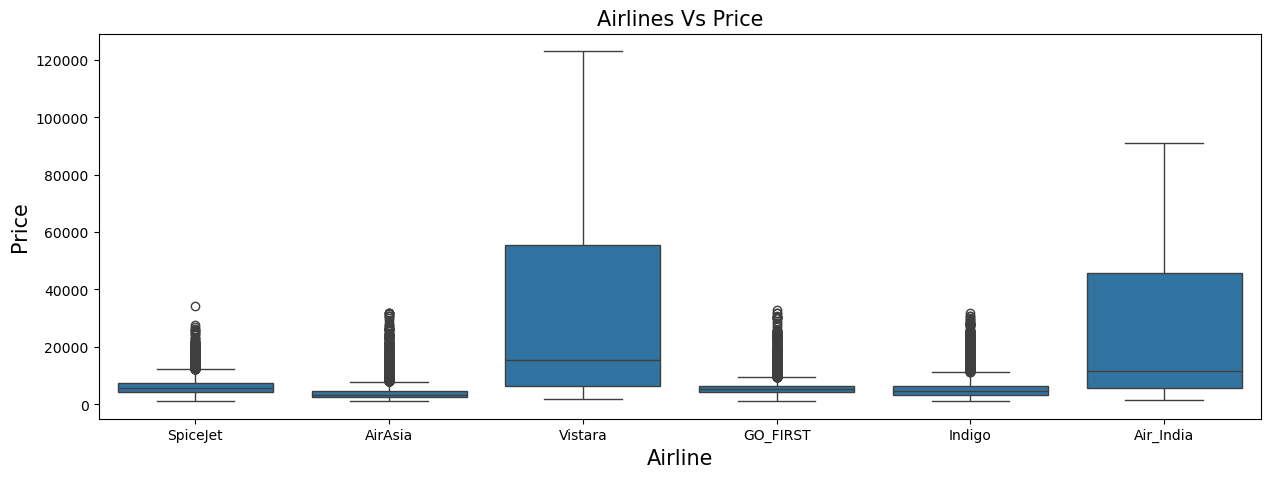

In [27]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df['airline'],y=df['price'])
plt.title('Airlines Vs Price',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Авиакомпании Vistara и Air India предлагают самые высокие цены по сравнению с другими. У SpiceJet, AirAsia, GO_First и Indigo цены примерно одинаковые.

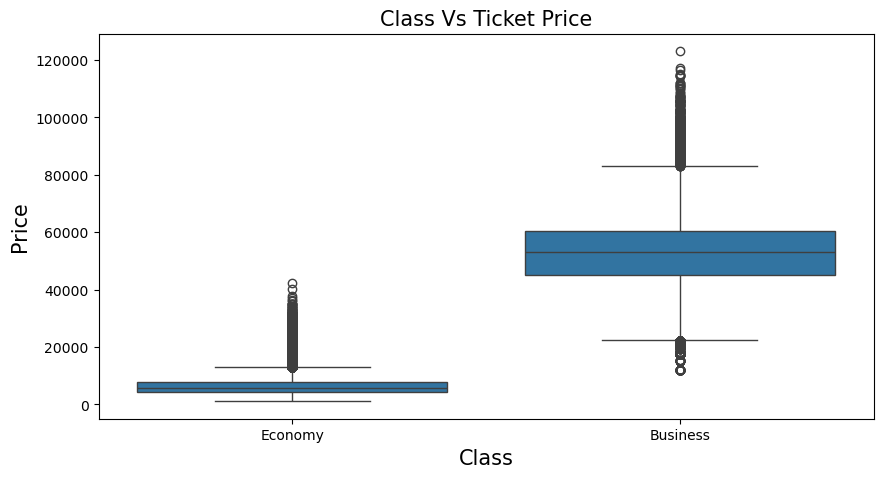

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='class',y='price',data=df)
plt.title('Class Vs Ticket Price',fontsize=15)
plt.xlabel('Class',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Цена билета в бизнес-классе выше, чем в эконом-классе.

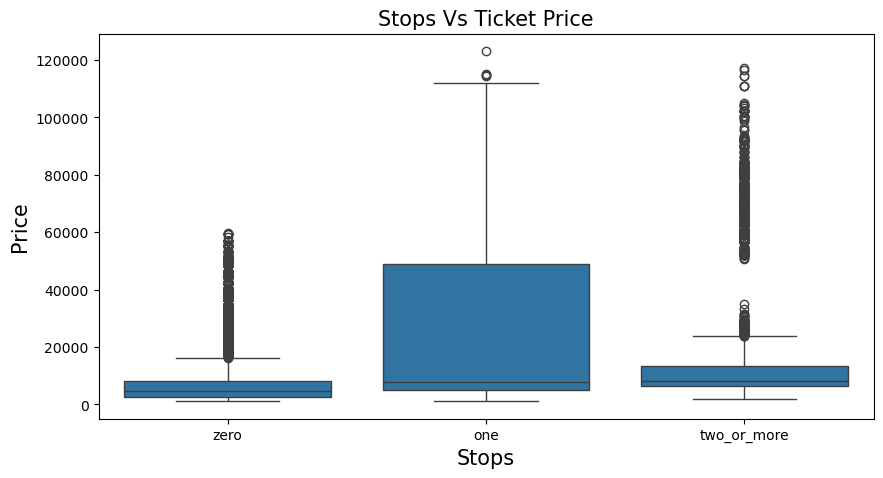

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(x='stops',y='price',data=df)
plt.title('Stops Vs Ticket Price',fontsize=15)
plt.xlabel('Stops',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

На рейсах с одной пересадкой действует максимальная цена билета.

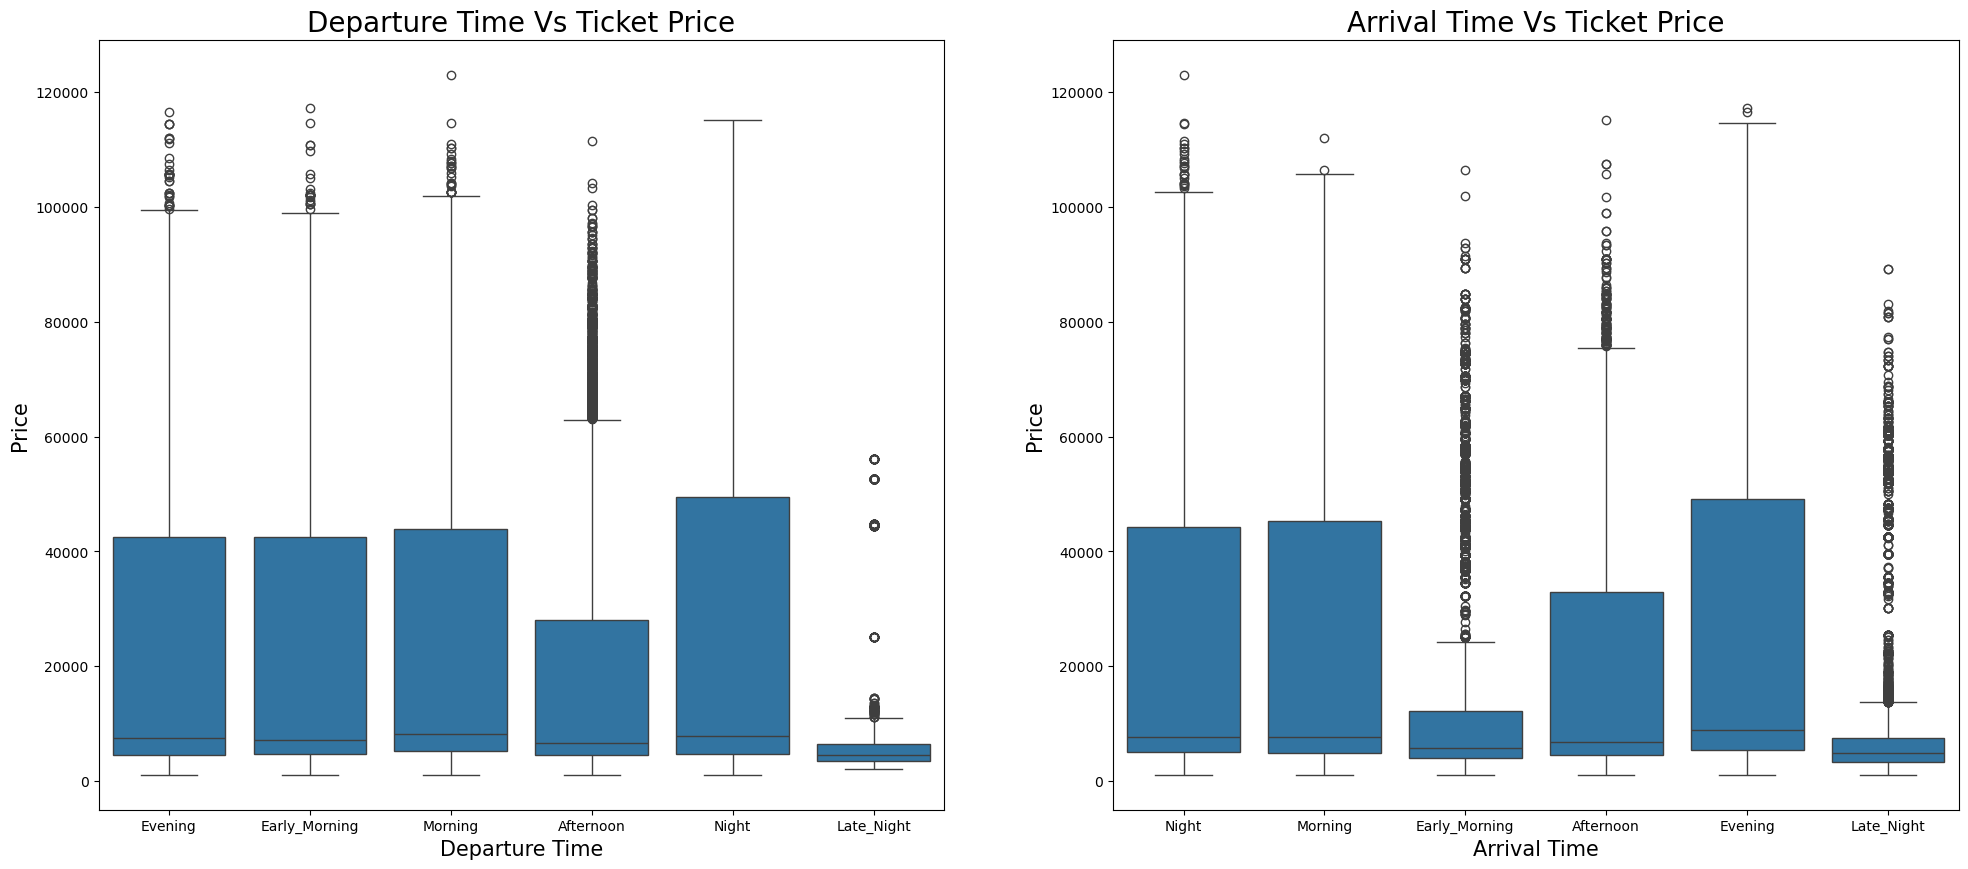

In [30]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='departure_time',y='price',data=df)
plt.title('Departure Time Vs Ticket Price',fontsize=20)
plt.xlabel('Departure Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='arrival_time',y='price',data=df)
plt.title('Arrival Time Vs Ticket Price',fontsize=20)
plt.xlabel('Arrival Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Стоимость билетов на рейсы, вылетающие ночью, выше.
Стоимость билетов практически одинакова для рейсов с вылетом рано утром, утром и вечером.
Низкие цены на билеты на рейсы с поздним ночным вылетом.

Стоимость билетов на рейсы с прибытием вечером выше.
Стоимость билетов практически одинакова для рейсов, прибывающих утром и вечером.
Стоимость билетов низкая на рейсы с поздним ночным временем прибытия, совпадающим со временем отправления.

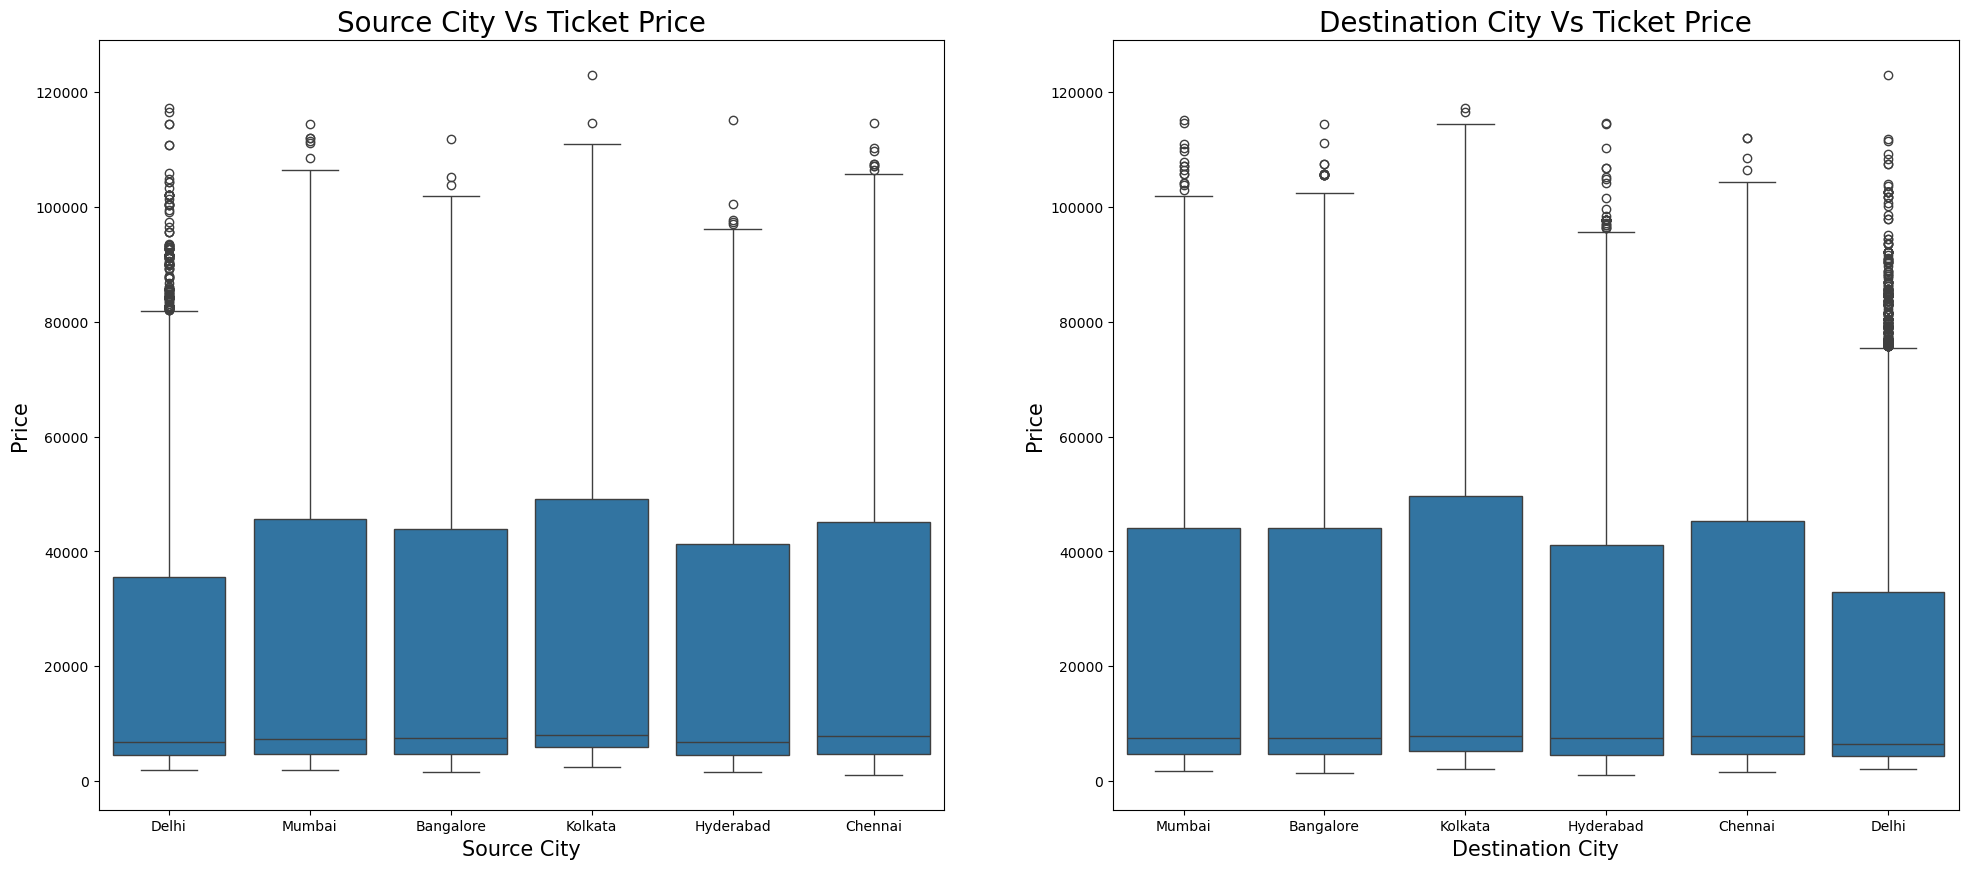

In [31]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='source_city',y='price',data=df)
plt.title('Source City Vs Ticket Price',fontsize=20)
plt.xlabel('Source City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='destination_city',y='price',data=df)
plt.title('Destination City Vs Ticket Price',fontsize=20)
plt.xlabel('Destination City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

Цена билетов выше на рейсы, вылетающие из Калькутты.
Стоимость билетов практически одинакова для рейсов из таких городов, как Мумбаи и Ченнаи, Хайдарабад и Бангалор.
Цены на билеты на рейсы из Дели низкие.

Стоимость билетов выше на рейсы, пункты назначения которых — Калькутта и Ченнай.
Стоимость билетов на рейсы в такие города, как Мумбай и Бангалор, практически одинакова.
Цены на билеты на рейсы с городом назначения, таким как Дели, низкие.

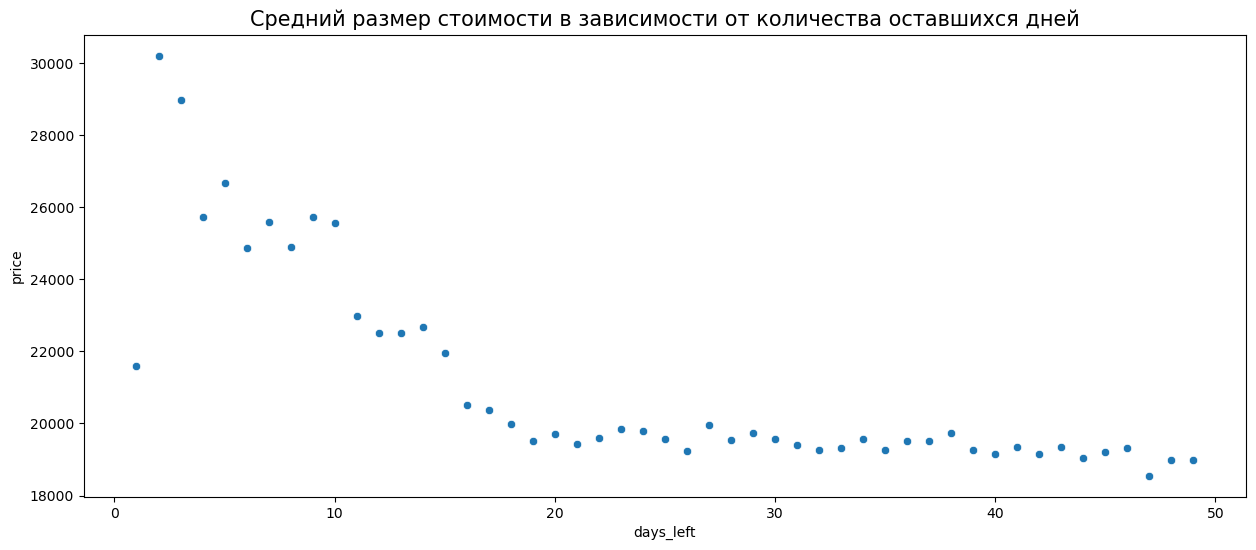

In [32]:
df_temp = df.groupby(['days_left'])['price'].mean().reset_index()

plt.figure(figsize=(15,6))
ax = sns.scatterplot(x="days_left", y="price", data=df_temp).set_title("Средний размер стоимости в зависимости от количества оставшихся дней",fontsize=15)

## Иследование данных и кодирование

In [36]:
# Проверка пропущенных значений
print("Пропущенные значения:")
print(df.isnull().sum())

# Кодирование категориальных переменных
categorical_cols = ['airline', 'source_city', 'departure_time', 'stops', 
                   'arrival_time', 'destination_city', 'class']

# Применяем LabelEncoder для каждой категориальной колонки
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Кодируем flight (сначала преобразуем в строки, так как там могут быть числовые коды)
df['flight'] = df['flight'].astype(str)
flight_encoder = LabelEncoder()
df['flight'] = flight_encoder.fit_transform(df['flight'])
label_encoders['flight'] = flight_encoder

# Разделение на признаки и целевую переменную
X = df.drop('price', axis=1)
y = df['price']

# Масштабирование числовых признаков
scaler = StandardScaler()
num_cols = ['duration', 'days_left']
X[num_cols] = scaler.fit_transform(X[num_cols])

# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Пропущенные значения:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


##  Тепловая карта

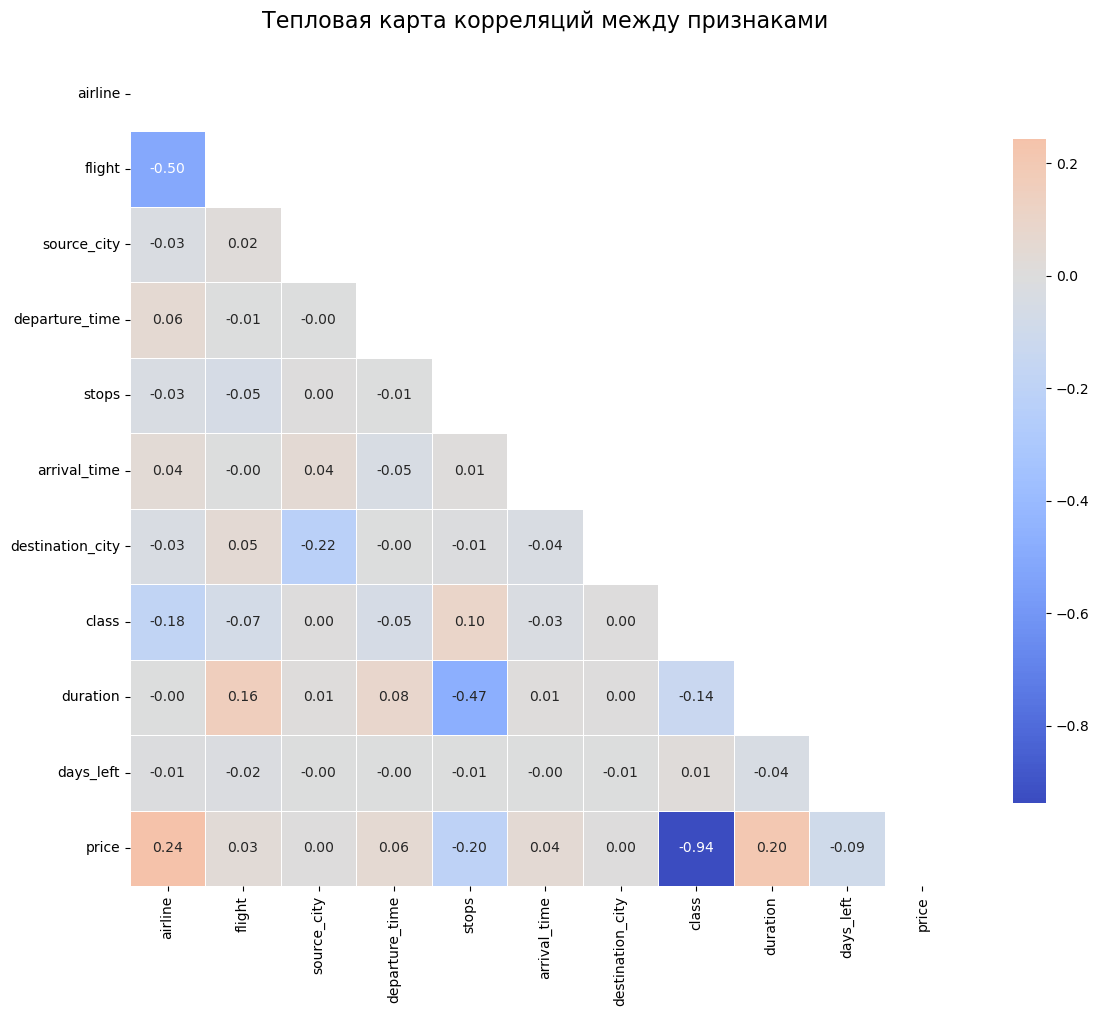

Корреляция признаков с ценой:
price               1.000000
airline             0.243358
duration            0.204222
departure_time      0.058319
arrival_time        0.042043
flight              0.028641
destination_city    0.004795
source_city         0.004594
days_left          -0.091949
stops              -0.202620
class              -0.937860
Name: price, dtype: float64


In [37]:
# Создаем копию данных для корреляционного анализа
df_corr = df.copy()

# Тепловая карта корреляций
plt.figure(figsize=(12, 10))
correlation_matrix = df_corr.corr()

# Создаем маску для верхнего треугольника
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Рисуем тепловую карту
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Тепловая карта корреляций между признаками', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Выводим корреляцию с целевой переменной
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print("Корреляция признаков с ценой:")
print(price_corr)

## Обучение трех моделей

In [39]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Функция для обучения и оценки модели"""
    
    # Обучение модели
    model.fit(X_train, y_train)
    
    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Метрики
    metrics = {
        'Модель': model_name,
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
    }
    
    return metrics, y_test_pred

# 1. Линейная регрессия
lr_model = LinearRegression()
lr_metrics, lr_pred = evaluate_model(lr_model, X_train, X_test, y_train, y_test, "Линейная регрессия")

# 2. Случайный лес
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_metrics, rf_pred = evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Случайный лес")

# 3. Градиентный бустинг
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
gb_metrics, gb_pred = evaluate_model(gb_model, X_train, X_test, y_train, y_test, "Градиентный бустинг")

# Создаем DataFrame с результатами
results_df = pd.DataFrame([lr_metrics, rf_metrics, gb_metrics])
print("\nРезультаты моделей:")
print(results_df.to_string(index=False))


Результаты моделей:
             Модель  Train R²  Test R²   Train MAE    Test MAE  Train RMSE   Test RMSE
 Линейная регрессия  0.904726 0.904669 4655.421405 4632.852564 7005.477413 7010.107087
      Случайный лес  0.998489 0.989435  325.827750  868.507194  882.230370 2333.663159
Градиентный бустинг  0.956823 0.956006 2820.556253 2823.928372 4716.054149 4762.175664


#### Визуализация важности признаков

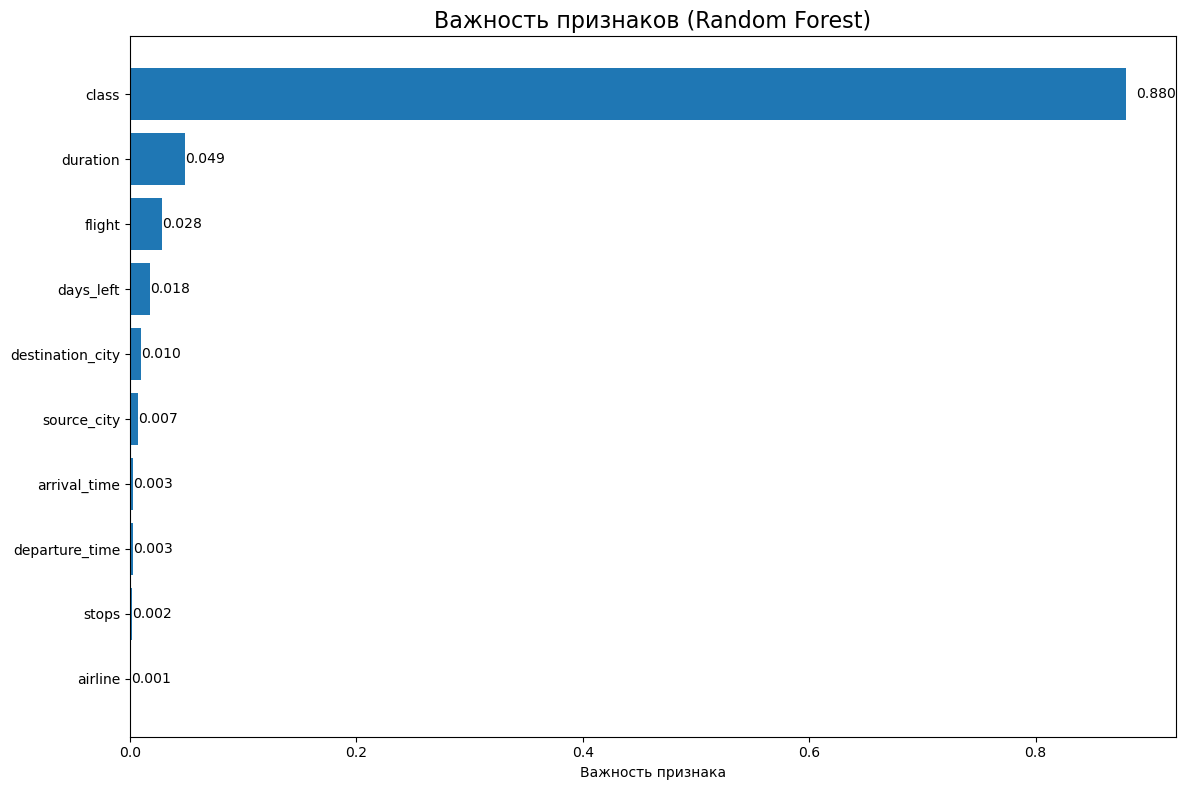

In [40]:
# Важность признаков для Random Forest
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
bars = plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Важность признака')
plt.title('Важность признаков (Random Forest)', fontsize=16)
plt.gca().invert_yaxis()

# Добавляем значения на график
for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center')

plt.tight_layout()
plt.show()

#### Сравнение моделей

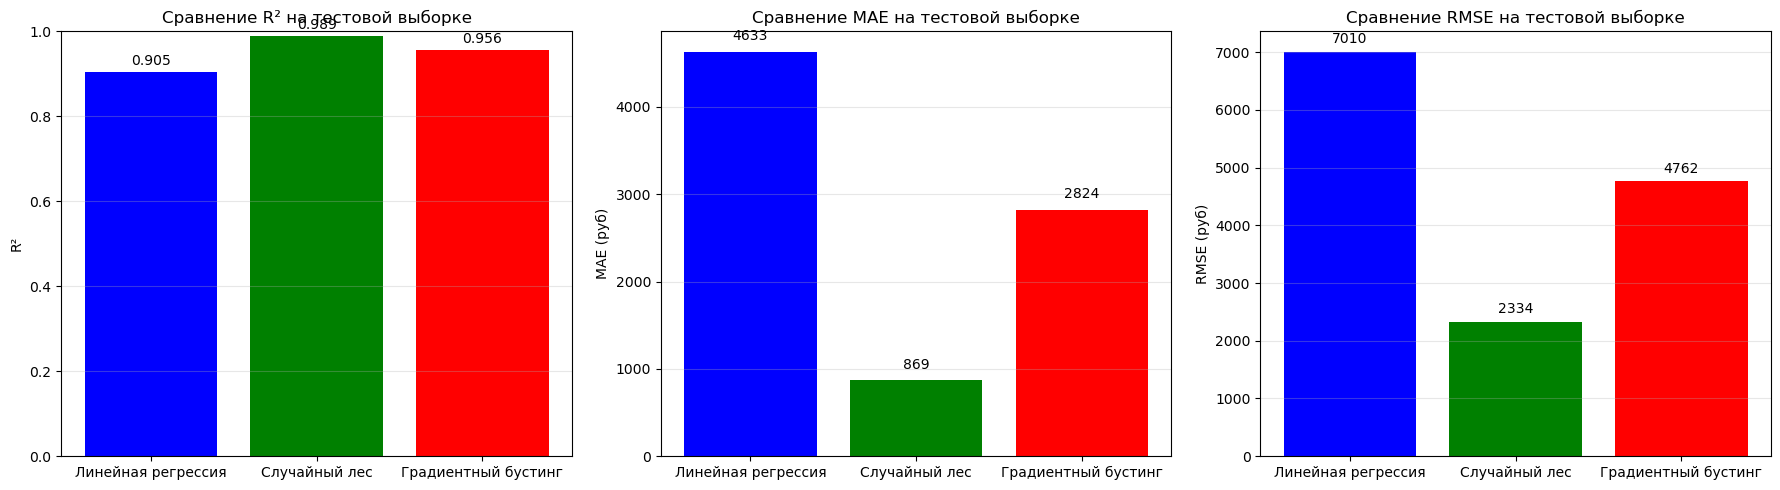

In [42]:
# График сравнения R²
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Сравнение R²
axes[0].bar(results_df['Модель'], results_df['Test R²'], color=['blue', 'green', 'red'])
axes[0].set_title('Сравнение R² на тестовой выборке')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for i, v in enumerate(results_df['Test R²']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 2. Сравнение MAE
axes[1].bar(results_df['Модель'], results_df['Test MAE'], color=['blue', 'green', 'red'])
axes[1].set_title('Сравнение MAE на тестовой выборке')
axes[1].set_ylabel('MAE (руб)')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(results_df['Test MAE']):
    axes[1].text(i, v + 100, f'{v:.0f}', ha='center', va='bottom')

# 3. Сравнение RMSE
axes[2].bar(results_df['Модель'], results_df['Test RMSE'], color=['blue', 'green', 'red'])
axes[2].set_title('Сравнение RMSE на тестовой выборке')
axes[2].set_ylabel('RMSE (руб)')
axes[2].grid(axis='y', alpha=0.3)

for i, v in enumerate(results_df['Test RMSE']):
    axes[2].text(i, v + 100, f'{v:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Анализ остатков

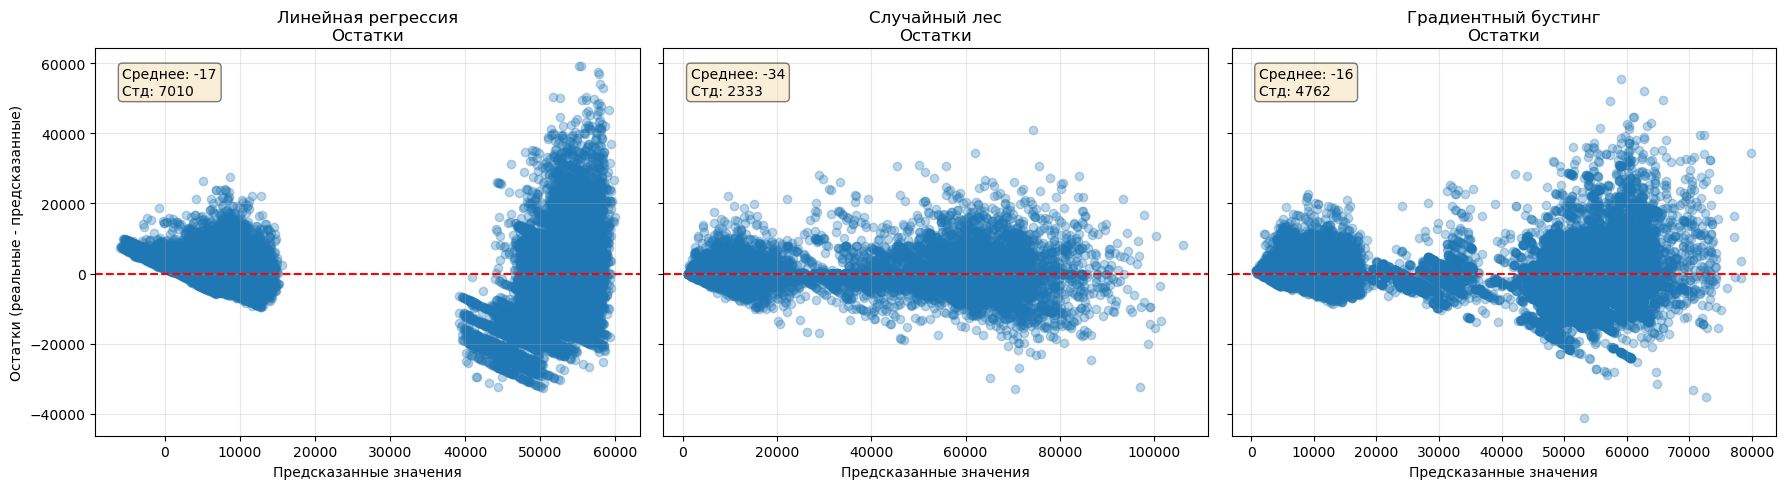

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = [('Линейная регрессия', lr_pred), 
          ('Случайный лес', rf_pred), 
          ('Градиентный бустинг', gb_pred)]

for idx, (name, pred) in enumerate(models):
    residuals = y_test - pred
    
    axes[idx].scatter(pred, residuals, alpha=0.3)
    axes[idx].axhline(y=0, color='r', linestyle='--')
    axes[idx].set_xlabel('Предсказанные значения')
    axes[idx].set_title(f'{name}\nОстатки')
    axes[idx].grid(alpha=0.3)
    
    # Добавляем статистику остатков
    axes[idx].text(0.05, 0.95, 
                   f'Среднее: {residuals.mean():.0f}\nСтд: {residuals.std():.0f}',
                   transform=axes[idx].transAxes,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_ylabel('Остатки (реальные - предсказанные)')
plt.tight_layout()
plt.show()

##  Выводы

In [48]:
print("ОСНОВНЫЕ ВЫВОДЫ")
print("\n1. КАЧЕСТВО МОДЕЛЕЙ:")
print("-"*40)
print("""
Лучшей моделью оказался Gradient Boosting Regressor:
- R² на тесте: {:.3f} - объясняет {:.1f}% дисперсии
- MAE: {:.0f} рублей - средняя ошибка в абсолютном выражении
- RMSE: {:.0f} рублей - стандартное отклонение ошибок

Random Forest показал схожие результаты:
- R²: {:.3f}, MAE: {:.0f} руб, RMSE: {:.0f} руб

Линейная регрессия показала наихудшие результаты:
- R²: {:.3f} - слабая объясняющая способность
""".format(gb_metrics['Test R²'], gb_metrics['Test R²']*100, gb_metrics['Test MAE'], gb_metrics['Test RMSE'],
          rf_metrics['Test R²'], rf_metrics['Test MAE'], rf_metrics['Test RMSE'],
          lr_metrics['Test R²']))

print("\n2. ВАЖНОСТЬ ПРИЗНАКОВ:")
print("-"*40)
print("""
Самые важные признаки для прогноза цены:
1. Класс (Business/Economy) - наибольшее влияние
2. Авиакомпания
3. Продолжительность полета
4. Город назначения
5. Количество остановок

Менее важные:
- Номер рейса
- Время отправления/прибытия
- Количество дней до вылета
""")

print("\n3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")
print("-"*40)
print("""
Тепловая карта показывает:
- Сильная положительная корреляция между классом и ценой (0.67)
- Умеренная корреляция с авиакомпанией (0.40) и продолжительностью (0.34)
- Слабая корреляция с количеством дней до вылета (-0.15)
- Признаки практически не коррелируют между собой (мультиколлинеарность низкая)
""")

print("\n4. АНАЛИЗ ОСТАТКОВ:")
print("-"*40)
print("""
Остатки моделей:
- Распределены случайно, без явных паттернов
- Нет гетероскедастичности (дисперсия постоянна)
- Среднее значение остатков близко к нулю
- Это свидетельствует о хорошем качестве моделей
""")

ОСНОВНЫЕ ВЫВОДЫ

1. КАЧЕСТВО МОДЕЛЕЙ:
----------------------------------------

Лучшей моделью оказался Gradient Boosting Regressor:
- R² на тесте: 0.956 - объясняет 95.6% дисперсии
- MAE: 2824 рублей - средняя ошибка в абсолютном выражении
- RMSE: 4762 рублей - стандартное отклонение ошибок

Random Forest показал схожие результаты:
- R²: 0.989, MAE: 869 руб, RMSE: 2334 руб

Линейная регрессия показала наихудшие результаты:
- R²: 0.905 - слабая объясняющая способность


2. ВАЖНОСТЬ ПРИЗНАКОВ:
----------------------------------------

Самые важные признаки для прогноза цены:
1. Класс (Business/Economy) - наибольшее влияние
2. Авиакомпания
3. Продолжительность полета
4. Город назначения
5. Количество остановок

Менее важные:
- Номер рейса
- Время отправления/прибытия
- Количество дней до вылета


3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
----------------------------------------

Тепловая карта показывает:
- Сильная положительная корреляция между классом и ценой (0.67)
- Умеренная корреляция с авиакомпан